In [1]:
# Cell 1: Imports and Setup
import sys
from pathlib import Path

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image

from dataset import VehicleDataset, get_transforms
from transfer_model import VehicleResNet, VehicleResNet34, VehicleEfficientNet

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
DATA_DIR = PROJECT_ROOT / "data" / "splits"
VAL_DIR = DATA_DIR / "val"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print(f"Project root: {PROJECT_ROOT}")

Using device: cuda
Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification


In [6]:
# Cell 2: Configuration
MODEL_TYPE = "efficientnet"  # Which model to analyze: "resnet18", "resnet34", "efficientnet"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 12

print(f"Analyzing model: {MODEL_TYPE}")
print(f"Checkpoint path: {OUTPUT_DIR / 'checkpoints' / MODEL_TYPE / 'best_model.pth'}")

Analyzing model: efficientnet
Checkpoint path: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\outputs\checkpoints\efficientnet\best_model.pth


In [7]:
# Cell 3: Load Dataset
val_transform = get_transforms('val', img_size=IMG_SIZE)
val_dataset = VehicleDataset(VAL_DIR, transform=val_transform)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {list(val_dataset.class_to_idx.keys())}")

Found 322 images in 12 classes
Validation samples: 322
Classes: ['class_01_motorcycle', 'class_02_passenger_car', 'class_03_four_tire_single_unit', 'class_04_bus', 'class_05_two_axle_six_tire_single_unit', 'class_06_three_axle_single_unit', 'class_07_four_or_more_axle_single_unit', 'class_08_four_or_less_axle_single_trailer', 'class_09_five_axle_tractor_semitrailer', 'class_10_six_or_more_axle_single_trailer', 'class_11_five_or_less_axle_multi_trailer', 'class_13_seven_or_more_axle_multi_trailer']


In [9]:
# Cell 4: Load Trained Model
if MODEL_TYPE == "resnet18":
    model = VehicleResNet(num_classes=NUM_CLASSES, pretrained=False)
elif MODEL_TYPE == "resnet34":
    model = VehicleResNet34(num_classes=NUM_CLASSES, pretrained=False)
elif MODEL_TYPE == "efficientnet":
    model = VehicleEfficientNet(num_classes=NUM_CLASSES, pretrained=False)

# Load best checkpoint
checkpoint_path = OUTPUT_DIR / "checkpoints" / MODEL_TYPE / "best_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Debug: See what's in the checkpoint
print(f"Checkpoint keys: {checkpoint.keys()}")

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# Safely print checkpoint info
print(f"\nLoaded model from epoch {checkpoint.get('epoch', 'unknown')}")
if 'val_acc' in checkpoint:
    print(f"Best validation accuracy: {checkpoint['val_acc']:.4f}")
else:
    print("Note: Validation accuracy not saved in checkpoint")
print("Model ready for error analysis!")

Loaded EfficientNet-B0 (pretrained=False, freeze_backbone=False)
Replaced classifier: 1280 -> 12
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_acc', 'history'])

Loaded model from epoch 62
Note: Validation accuracy not saved in checkpoint
Model ready for error analysis!


In [10]:
# Cell 5: Get All Predictions and Identify Errors
def get_predictions_with_paths(model, dataset, loader, device):
    """Get predictions, true labels, and image paths."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Getting predictions...")
val_preds, val_labels, val_probs = get_predictions_with_paths(model, val_dataset, val_loader, device)

# Find misclassified samples
errors = val_preds != val_labels
error_indices = np.where(errors)[0]
correct_indices = np.where(~errors)[0]

print(f"\nTotal samples: {len(val_labels)}")
print(f"Correct predictions: {len(correct_indices)} ({100*len(correct_indices)/len(val_labels):.2f}%)")
print(f"Errors: {len(error_indices)} ({100*len(error_indices)/len(val_labels):.2f}%)")

Getting predictions...

Total samples: 322
Correct predictions: 289 (89.75%)
Errors: 33 (10.25%)


In [11]:
# Cell 6: Per-Class Error Analysis
print("Per-Class Error Analysis:")
print("=" * 80)

class_errors = {}
for class_idx in range(NUM_CLASSES):
    class_name = val_dataset.idx_to_class[class_idx]
    class_mask = val_labels == class_idx
    class_total = class_mask.sum()
    class_correct = ((val_preds == val_labels) & class_mask).sum()
    class_error = class_total - class_correct
    error_rate = (class_error / class_total * 100) if class_total > 0 else 0
    
    class_errors[class_name] = {
        'total': class_total,
        'correct': class_correct,
        'errors': class_error,
        'error_rate': error_rate
    }
    
    print(f"{class_name:40s} | Total: {class_total:3d} | Errors: {class_error:2d} | Error Rate: {error_rate:5.1f}%")

# Sort by error rate
sorted_classes = sorted(class_errors.items(), key=lambda x: x[1]['error_rate'], reverse=True)
print("\nWorst performing classes:")
for class_name, stats in sorted_classes[:5]:
    print(f"  {class_name}: {stats['error_rate']:.1f}% error rate ({stats['errors']}/{stats['total']})")

Per-Class Error Analysis:
class_01_motorcycle                      | Total:  43 | Errors:  0 | Error Rate:   0.0%
class_02_passenger_car                   | Total: 148 | Errors:  9 | Error Rate:   6.1%
class_03_four_tire_single_unit           | Total:  10 | Errors:  1 | Error Rate:  10.0%
class_04_bus                             | Total:  39 | Errors:  1 | Error Rate:   2.6%
class_05_two_axle_six_tire_single_unit   | Total:  12 | Errors:  3 | Error Rate:  25.0%
class_06_three_axle_single_unit          | Total:  19 | Errors:  5 | Error Rate:  26.3%
class_07_four_or_more_axle_single_unit   | Total:   6 | Errors:  5 | Error Rate:  83.3%
class_08_four_or_less_axle_single_trailer | Total:   9 | Errors:  2 | Error Rate:  22.2%
class_09_five_axle_tractor_semitrailer   | Total:  12 | Errors:  2 | Error Rate:  16.7%
class_10_six_or_more_axle_single_trailer | Total:   8 | Errors:  3 | Error Rate:  37.5%
class_11_five_or_less_axle_multi_trailer | Total:   6 | Errors:  0 | Error Rate:   0.0%
class

In [12]:
# Cell 7: Confusion Analysis - Most Common Confusions
cm = confusion_matrix(val_labels, val_preds)

# Find top confusion pairs (excluding diagonal)
confusion_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((
                val_dataset.idx_to_class[i],
                val_dataset.idx_to_class[j],
                cm[i, j]
            ))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 10 Confusion Pairs:")
print("=" * 80)
print(f"{'True Class':<40s} → {'Predicted Class':<40s} | Count")
print("=" * 80)
for true_class, pred_class, count in confusion_pairs[:10]:
    print(f"{true_class:<40s} → {pred_class:<40s} | {count:3d}")

Top 10 Confusion Pairs:
True Class                               → Predicted Class                          | Count
class_02_passenger_car                   → class_03_four_tire_single_unit           |   7
class_05_two_axle_six_tire_single_unit   → class_06_three_axle_single_unit          |   3
class_06_three_axle_single_unit          → class_07_four_or_more_axle_single_unit   |   2
class_07_four_or_more_axle_single_unit   → class_06_three_axle_single_unit          |   2
class_07_four_or_more_axle_single_unit   → class_08_four_or_less_axle_single_trailer |   2
class_10_six_or_more_axle_single_trailer → class_09_five_axle_tractor_semitrailer   |   2
class_13_seven_or_more_axle_multi_trailer → class_09_five_axle_tractor_semitrailer   |   2
class_02_passenger_car                   → class_01_motorcycle                      |   1
class_02_passenger_car                   → class_05_two_axle_six_tire_single_unit   |   1
class_03_four_tire_single_unit           → class_02_passenger_car       

Misclassified samples for: class_07_four_or_more_axle_single_unit
Error rate: 83.3%


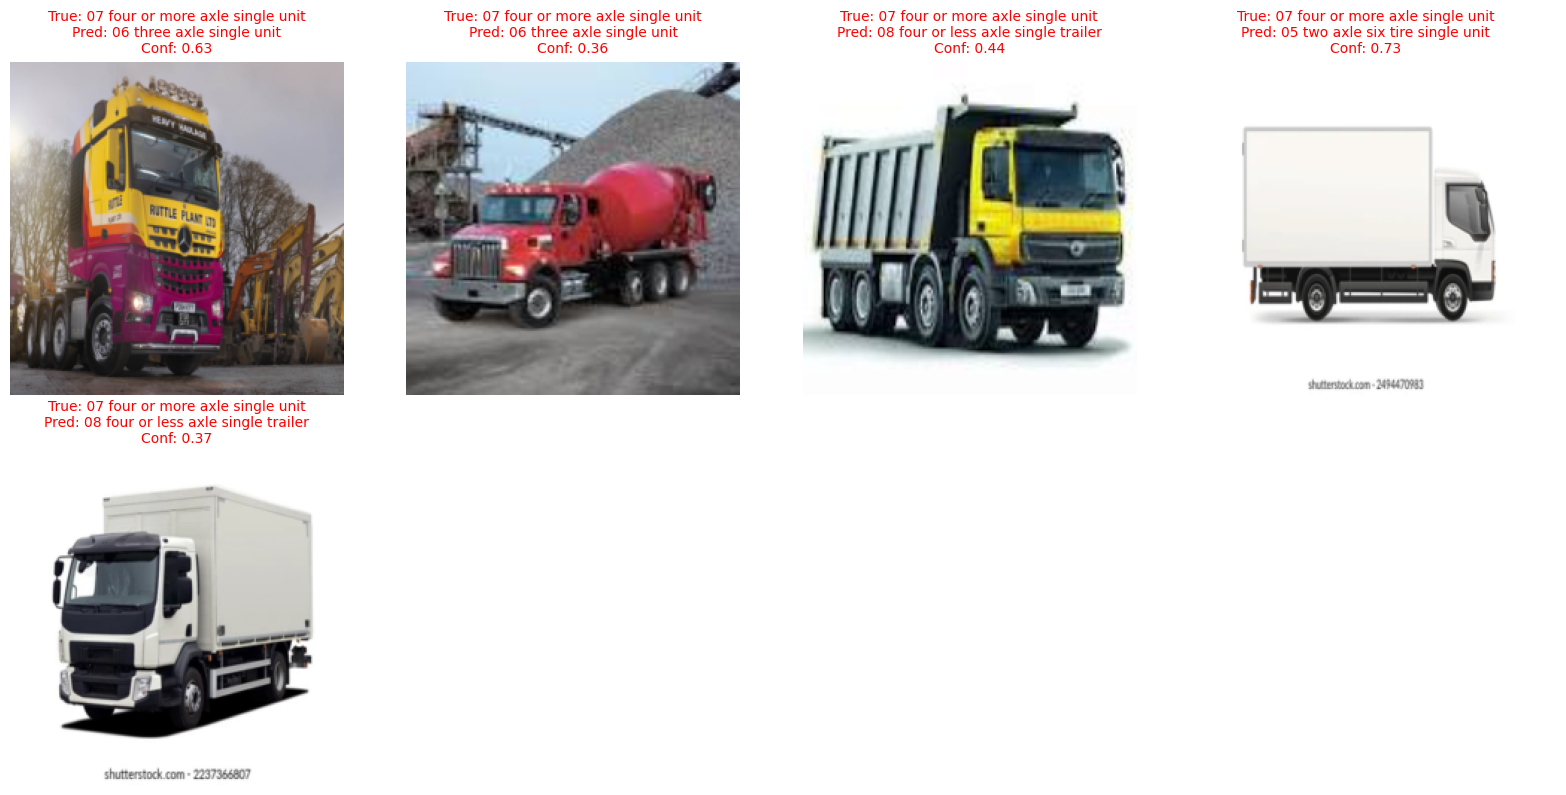

In [14]:
# Cell 8: Visualize Misclassified Images - Worst Performing Class
def denormalize(tensor):
    """Denormalize image tensor for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def plot_misclassified_samples(dataset, error_indices, true_labels, pred_labels, probs, 
                                target_class=None, max_samples=12):
    """Plot misclassified samples for a specific class."""
    if target_class is not None:
        # Filter errors for target class
        class_error_mask = true_labels[error_indices] == target_class
        class_error_indices = error_indices[class_error_mask]
    else:
        class_error_indices = error_indices
    
    n_samples = min(len(class_error_indices), max_samples)
    if n_samples == 0:
        print(f"No errors found for class {target_class}")
        return
    
    rows = (n_samples + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4*rows))
    axes = axes.flatten() if n_samples > 4 else [axes] if n_samples == 1 else axes
    
    for idx, error_idx in enumerate(class_error_indices[:max_samples]):
        img, true_label = dataset[error_idx]
        pred_label = pred_labels[error_idx]
        confidence = probs[error_idx][pred_label]
        
        img_display = denormalize(img).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
        
        axes[idx].imshow(img_display)
        axes[idx].axis('off')
        
        true_name = dataset.idx_to_class[true_label].replace('class_', '').replace('_', ' ')
        pred_name = dataset.idx_to_class[pred_label].replace('class_', '').replace('_', ' ')
        
        axes[idx].set_title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2f}",
            fontsize=10, color='red'
        )
    
    # Hide unused subplots
    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

# Plot errors for worst performing class
worst_class_name = sorted_classes[0][0]
worst_class_idx = val_dataset.class_to_idx[worst_class_name]

print(f"Misclassified samples for: {worst_class_name}")
print(f"Error rate: {sorted_classes[0][1]['error_rate']:.1f}%")
fig = plot_misclassified_samples(val_dataset, error_indices, val_labels, val_preds, val_probs, 
                                  target_class=worst_class_idx, max_samples=12)
if fig:
    plt.savefig(OUTPUT_DIR / "plots" / f"errors_{worst_class_name}_{MODEL_TYPE}.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

Most common confusion: class_02_passenger_car → class_03_four_tire_single_unit (7 samples)


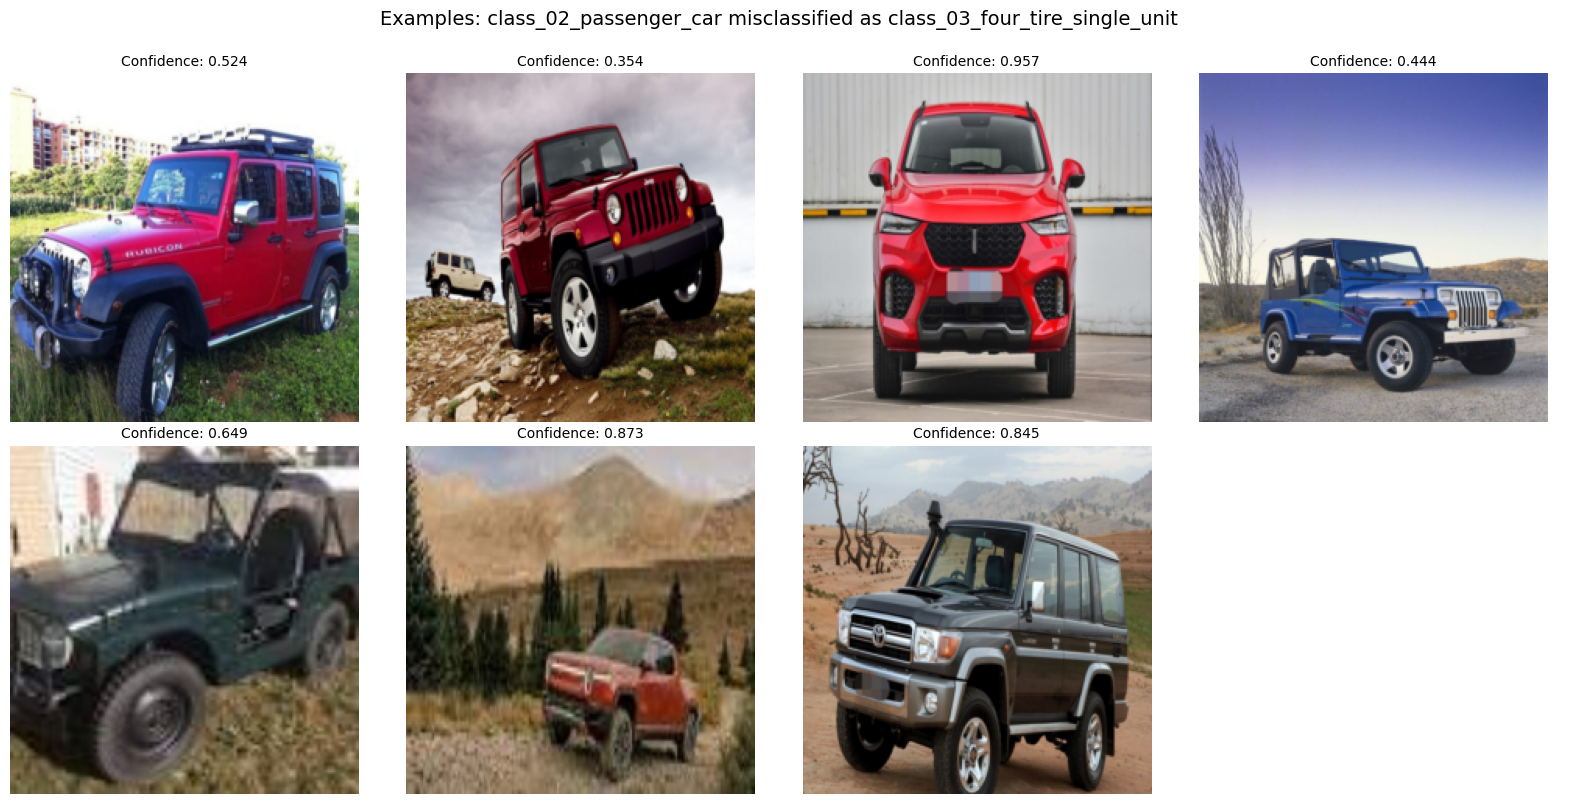

In [15]:
# Cell 9: Visualize Specific Confusion Pair
# Analyze the most common confusion
if len(confusion_pairs) > 0:
    true_class_name, pred_class_name, count = confusion_pairs[0]
    true_class_idx = val_dataset.class_to_idx[true_class_name]
    pred_class_idx = val_dataset.class_to_idx[pred_class_name]
    
    print(f"Most common confusion: {true_class_name} → {pred_class_name} ({count} samples)")
    
    # Find specific confusion cases
    confusion_mask = (val_labels == true_class_idx) & (val_preds == pred_class_idx)
    confusion_indices = np.where(confusion_mask)[0]
    
    rows = min(3, (len(confusion_indices) + 3) // 4)
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4*rows))
    axes = axes.flatten() if len(confusion_indices) > 4 else [axes] if len(confusion_indices) == 1 else axes
    
    for idx, conf_idx in enumerate(confusion_indices[:12]):
        img, true_label = val_dataset[conf_idx]
        pred_label = val_preds[conf_idx]
        confidence = val_probs[conf_idx][pred_label]
        
        img_display = denormalize(img).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)
        
        axes[idx].imshow(img_display)
        axes[idx].axis('off')
        axes[idx].set_title(f"Confidence: {confidence:.3f}", fontsize=10)
    
    for idx in range(len(confusion_indices[:12]), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"Examples: {true_class_name} misclassified as {pred_class_name}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "plots" / f"confusion_{true_class_name}_to_{pred_class_name}_{MODEL_TYPE}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No confusions found!")

C:\Users\amrem\AppData\Local\Temp\ipykernel_28712\2111094616.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([correct_confidences, error_confidences], labels=['Correct', 'Errors'])


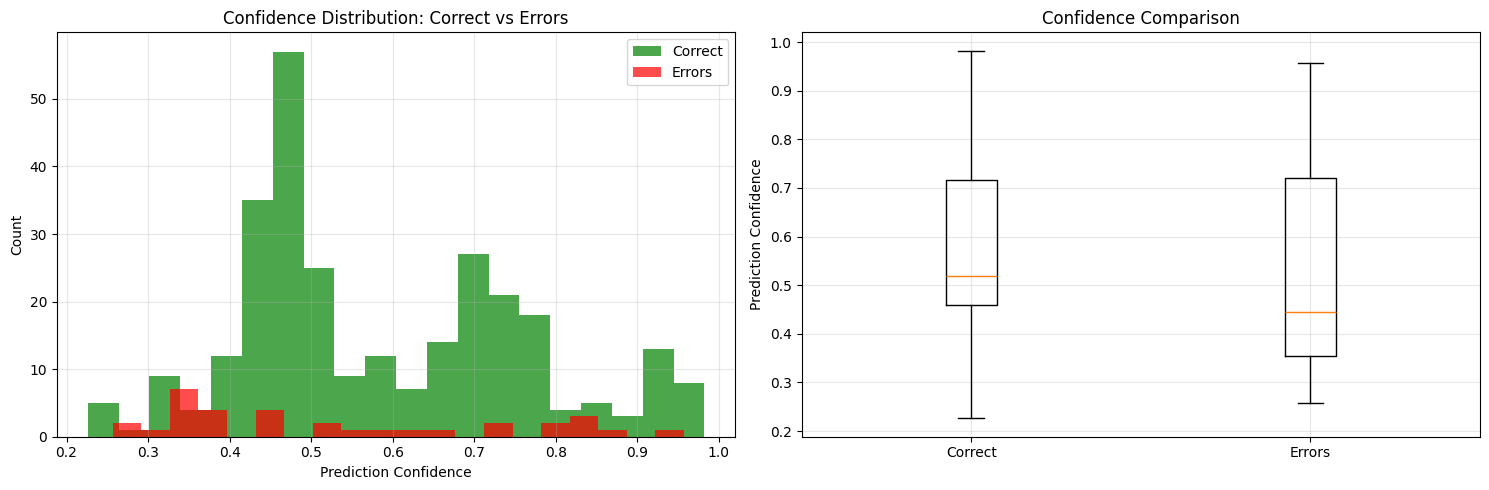

Average confidence for correct predictions: 0.586
Average confidence for errors: 0.527

High confidence errors (>0.8): 5


In [16]:
# Cell 10: Confidence Analysis for Errors
error_confidences = []
correct_confidences = []

for i in range(len(val_labels)):
    confidence = val_probs[i][val_preds[i]]
    if i in error_indices:
        error_confidences.append(confidence)
    else:
        correct_confidences.append(confidence)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
ax1.hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green')
ax1.hist(error_confidences, bins=20, alpha=0.7, label='Errors', color='red')
ax1.set_xlabel('Prediction Confidence')
ax1.set_ylabel('Count')
ax1.set_title('Confidence Distribution: Correct vs Errors')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot([correct_confidences, error_confidences], labels=['Correct', 'Errors'])
ax2.set_ylabel('Prediction Confidence')
ax2.set_title('Confidence Comparison')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / f"confidence_analysis_{MODEL_TYPE}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Average confidence for correct predictions: {np.mean(correct_confidences):.3f}")
print(f"Average confidence for errors: {np.mean(error_confidences):.3f}")
print(f"\nHigh confidence errors (>0.8): {sum(1 for c in error_confidences if c > 0.8)}")

In [18]:
# Cell 11: Summary and Recommendations
print("=" * 80)
print("ERROR ANALYSIS SUMMARY")
print("=" * 80)

print(f"\nModel: {MODEL_TYPE.upper()}")
print(f"Overall Accuracy: {100 * len(correct_indices) / len(val_labels):.2f}%")
print(f"Total Errors: {len(error_indices)} / {len(val_labels)}")

print("\n📊 TOP 3 PROBLEM CLASSES:")
for i, (class_name, stats) in enumerate(sorted_classes[:3], 1):
    print(f"{i}. {class_name}")
    print(f"   - Error Rate: {stats['error_rate']:.1f}%")
    print(f"   - Sample Size: {stats['total']} (small={stats['total']<15})")
    print(f"   - Errors: {stats['errors']}")

print("\n🔄 TOP 3 CONFUSION PAIRS:")
for i, (true_cls, pred_cls, cnt) in enumerate(confusion_pairs[:3], 1):
    print(f"{i}. {true_cls} → {pred_cls}: {cnt} cases")


ERROR ANALYSIS SUMMARY

Model: EFFICIENTNET
Overall Accuracy: 89.75%
Total Errors: 33 / 322

📊 TOP 3 PROBLEM CLASSES:
1. class_07_four_or_more_axle_single_unit
   - Error Rate: 83.3%
   - Sample Size: 6 (small=True)
   - Errors: 5
2. class_10_six_or_more_axle_single_trailer
   - Error Rate: 37.5%
   - Sample Size: 8 (small=True)
   - Errors: 3
3. class_06_three_axle_single_unit
   - Error Rate: 26.3%
   - Sample Size: 19 (small=False)
   - Errors: 5

🔄 TOP 3 CONFUSION PAIRS:
1. class_02_passenger_car → class_03_four_tire_single_unit: 7 cases
2. class_05_two_axle_six_tire_single_unit → class_06_three_axle_single_unit: 3 cases
3. class_06_three_axle_single_unit → class_07_four_or_more_axle_single_unit: 2 cases
